# Sampling validity check: dropped vs. retained cubes

**Question.** `Data-prep.ipynb` filters the raw 2216-cube dataset down to the 1,975 cubes that
contain at least one disturbance pixel in any year (2016-2022), dropping the other 241. A stated
limitation of the resulting model is that this filter could be removing more than "easy negatives":

> Disturbance-containing cubes are plausibly a different landscape type, not just a
> higher-prevalence draw of the same one. Cubes that record disturbance skew toward production
> forest, accessible terrain, and drought- or beetle-stressed regions; cubes with none skew toward
> protected, remote, or climatically stable stands. If that holds, the filter removed a covariate
> regime, not merely a set of easy negatives.

This notebook tests that hypothesis directly against `full_dataset_resizedv2.zarr` (the full
2216-cube population, before the disturbance filter is applied) by comparing the 241 dropped cubes
against the 1,975 retained cubes on three landscape covariates:

- **DEM** (mean elevation, meters) — proxy for the "accessible terrain" claim
- **Forest-mask fraction** (`forest_mask_static`) — proxy for "production forest" vs. non-forest / sparse-forest landscape
- **Mean NDVI** (from Sentinel-2 `B8A`/`B04`, best-of-topK composite) — proxy for vegetation vigor / stress, computed both cube-wide and restricted to forest pixels only (to separate "less forest" from "different-looking forest")

**Outcome.** Either the two groups look statistically indistinguishable on these covariates — in
which case the concern collapses to pure class-prevalence imbalance and the filter is defensible as
"removing easy negatives" — or they differ in ways that support a real covariate-regime shift.

In [1]:
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / ".git").exists():
            return p
    raise RuntimeError("Could not locate project root (no .git found above cwd)")

PROJECT_ROOT = _find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"


In [2]:
import time
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats

from src.cube.prepare import restore_dataset_attrs


## 1. Load the full (unfiltered) cube population

In [3]:
DATA_PATH = PROJECT_ROOT / 'full_dataset_resizedv2.zarr'

print('Loading data from zarr...')
data = xr.open_dataset(DATA_PATH, engine='zarr', mask_and_scale=True)
data = restore_dataset_attrs(data)
n_cubes = data.sizes['cube']
print(f'✓ Data loaded: {n_cubes} cubes')


Loading data from zarr...


C:\Users\bartu\Desktop\Fonda-scikit - Git\src\cube\prepare.py:39: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'stat_weather'} to avoid an error in the future.
  cube_data["weather_stats"] = cube_data["weather_stats"].stack(stat_weather=("statistic", "weather_band"))
C:\Users\bartu\Desktop\Fonda-scikit - Git\src\cube\prepare.py:40: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'stat_weather'} to avoid an error in the future.
  cube_data["weather_stats_norm"] = cube_data["weather_stats_norm"].stack(stat_weather=("statistic", "weather_band"))


✓ Data loaded: 2216 cubes


## 2. Reproduce the disturbance filter from `Data-prep.ipynb`

Same logic as that notebook's "Filter Cubes with Disturbances" cell — a cube is **retained** if it
has at least one disturbance pixel in any year, and **dropped** otherwise. This must reproduce the
241/1,975 split exactly; if it doesn't, the rest of this analysis is checking the wrong population.

In [4]:
original_cube_count = data.sizes["cube"]
spatial_dims = ['year', 'x', 'y']

has_disturbance = (data['disturbances'] == 1).any(dim=spatial_dims).values  # (cube,) bool
cube_names_all = data['cube'].values

n_retained = int(has_disturbance.sum())
n_dropped = int((~has_disturbance).sum())

print(f'Original cubes: {original_cube_count}')
print(f'Retained (has disturbance): {n_retained}')
print(f'Dropped (no disturbance ever): {n_dropped}')

assert n_retained == 1975 and n_dropped == 241, \
    f'Split does not match expected 1975/241 (got {n_retained}/{n_dropped}) — check filter logic before trusting results below.'
print('✓ Matches expected 1,975 retained / 241 dropped split')


Original cubes: 2216
Retained (has disturbance): 1975
Dropped (no disturbance ever): 241
✓ Matches expected 1,975 retained / 241 dropped split


## 3. Compute per-cube landscape covariates

For each of the 2216 cubes: mean DEM elevation, forest-mask fraction (`forest_mask_static`, with
the `255` no-data sentinel excluded), mean NDVI over the whole cube, and mean NDVI restricted to
forest pixels only. NDVI uses band `B8A` (NIR) and `B04` (Red) from the best-of-`topK` Sentinel-2
composite, matching the NDVI convention used elsewhere in `Data-prep.ipynb`.

Chunk layout is one cube per chunk (`(1, ...)` along `cube`), so a plain per-cube loop reads exactly
one chunk at a time — no need for dask here.

In [5]:
band_names = list(data['s2_band'].values)
nir_idx = band_names.index('B8A')
red_idx = band_names.index('B04')

records = []
t0 = time.time()
for i in range(original_cube_count):
    dem = data['dem'].isel(cube=i).values[..., 0]  # (y, x)
    dem_mean = float(np.nanmean(dem))

    fms = data['forest_mask_static'].isel(cube=i).values.astype(float)  # (y, x), 0/1, 255=no-data
    fms[fms == 255] = np.nan
    forest_frac = float(np.nanmean(fms))

    s2 = data['S2'].isel(cube=i, topK=0).values  # (year, y, x, s2_band)
    nir = s2[..., nir_idx]
    red = s2[..., red_idx]
    denom = nir + red
    with np.errstate(invalid='ignore'):
        ndvi = np.where(denom != 0, (nir - red) / denom, np.nan)  # (year, y, x)
    ndvi_mean = float(np.nanmean(ndvi))

    forest_bool = data['forest_mask_static'].isel(cube=i).values == 1  # (y, x)
    ndvi_forest_mean = float(np.nanmean(ndvi[:, forest_bool])) if forest_bool.any() else np.nan

    records.append({
        'cube': str(cube_names_all[i]),
        'cube_idx': i,
        'dropped': not bool(has_disturbance[i]),
        'dem_mean': dem_mean,
        'forest_frac': forest_frac,
        'ndvi_mean': ndvi_mean,
        'ndvi_forest_mean': ndvi_forest_mean,
    })

df = pd.DataFrame.from_records(records)
print(f'Computed covariates for {len(df)} cubes in {time.time() - t0:.1f}s')
df['dropped'].value_counts()


Computed covariates for 2216 cubes in 72.0s


dropped
False    1975
True      241
Name: count, dtype: int64

In [6]:
OUT_DIR = PROJECT_ROOT / 'experiments' / 'sampling_validity_check'
OUT_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_DIR / 'dropped_vs_retained_covariates.csv', index=False)
df.head()


,cube,cube_idx,dropped,dem_mean,forest_frac,ndvi_mean,ndvi_forest_mean
0,mc_-0.04_51.09_1.2_20230627_0,0,False,121.967991,0.415771,0.736029,0.814158
1,mc_-0.06_44.09_1.2_20230627_0,1,False,152.755790,0.740601,0.696564,0.732028
2,mc_-0.06_51.21_1.2_20230627_0,2,False,78.785749,0.185120,0.689050,0.780097
3,mc_-0.28_45.20_1.2_20230627_0,3,False,93.954391,0.782898,0.701545,0.762317
4,mc_-0.43_44.22_1.2_20230627_0,4,False,108.551875,0.872131,0.693674,0.730028


## 4. Compare dropped vs. retained

In [7]:
metrics = ['dem_mean', 'forest_frac', 'ndvi_mean', 'ndvi_forest_mean']
labels = {
    'dem_mean': 'DEM (mean elevation, m)',
    'forest_frac': 'Forest-mask fraction',
    'ndvi_mean': 'Mean NDVI (whole cube)',
    'ndvi_forest_mean': 'Mean NDVI (forest pixels only)',
}

rows = []
for col in metrics:
    a = df.loc[df['dropped'], col].dropna()   # dropped
    b = df.loc[~df['dropped'], col].dropna()  # retained

    u, p_mw = stats.mannwhitneyu(a, b, alternative='two-sided')
    t, p_t = stats.ttest_ind(a, b, equal_var=False)
    pooled_std = np.sqrt(((len(a) - 1) * a.std(ddof=1) ** 2 + (len(b) - 1) * b.std(ddof=1) ** 2) / (len(a) + len(b) - 2))
    cohend = (a.mean() - b.mean()) / pooled_std

    rows.append({
        'metric': labels[col],
        'dropped_mean': a.mean(), 'dropped_median': a.median(), 'dropped_std': a.std(),
        'retained_mean': b.mean(), 'retained_median': b.median(), 'retained_std': b.std(),
        'cohens_d': cohend,
        'mannwhitney_p': p_mw,
        'welch_t_p': p_t,
    })

summary = pd.DataFrame(rows).set_index('metric')
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
summary


,dropped_mean,dropped_median,dropped_std,retained_mean,retained_median,retained_std,cohens_d,mannwhitney_p,welch_t_p
metric,,,,,,,,,
"DEM (mean elevation, m)",563.7,279.5,682.4,520.3,365.4,452.7,0.08991,0.009653,0.3368
Forest-mask fraction,0.2077,0.06812,0.2699,0.603,0.618,0.2459,-1.59,2.276e-73,1.278e-62
Mean NDVI (whole cube),0.5757,0.5986,0.1454,0.7146,0.726,0.08134,-1.534,7.269e-58,1.926e-35
Mean NDVI (forest pixels only),0.7547,0.7788,0.102,0.7857,0.801,0.06073,-0.4666,4.031e-05,6.05e-06


**Reading the effect size:** `|d| < 0.2` is negligible, `~0.5` is moderate, `> 0.8` is large,
by Cohen's conventional bands. The Mann-Whitney p-value is the primary significance test here
(distributions are visibly non-normal / skewed for `forest_frac` and `dem_mean`, so it's more
trustworthy than the t-test); Welch's t is reported alongside it for reference.

## 5. Visual comparison

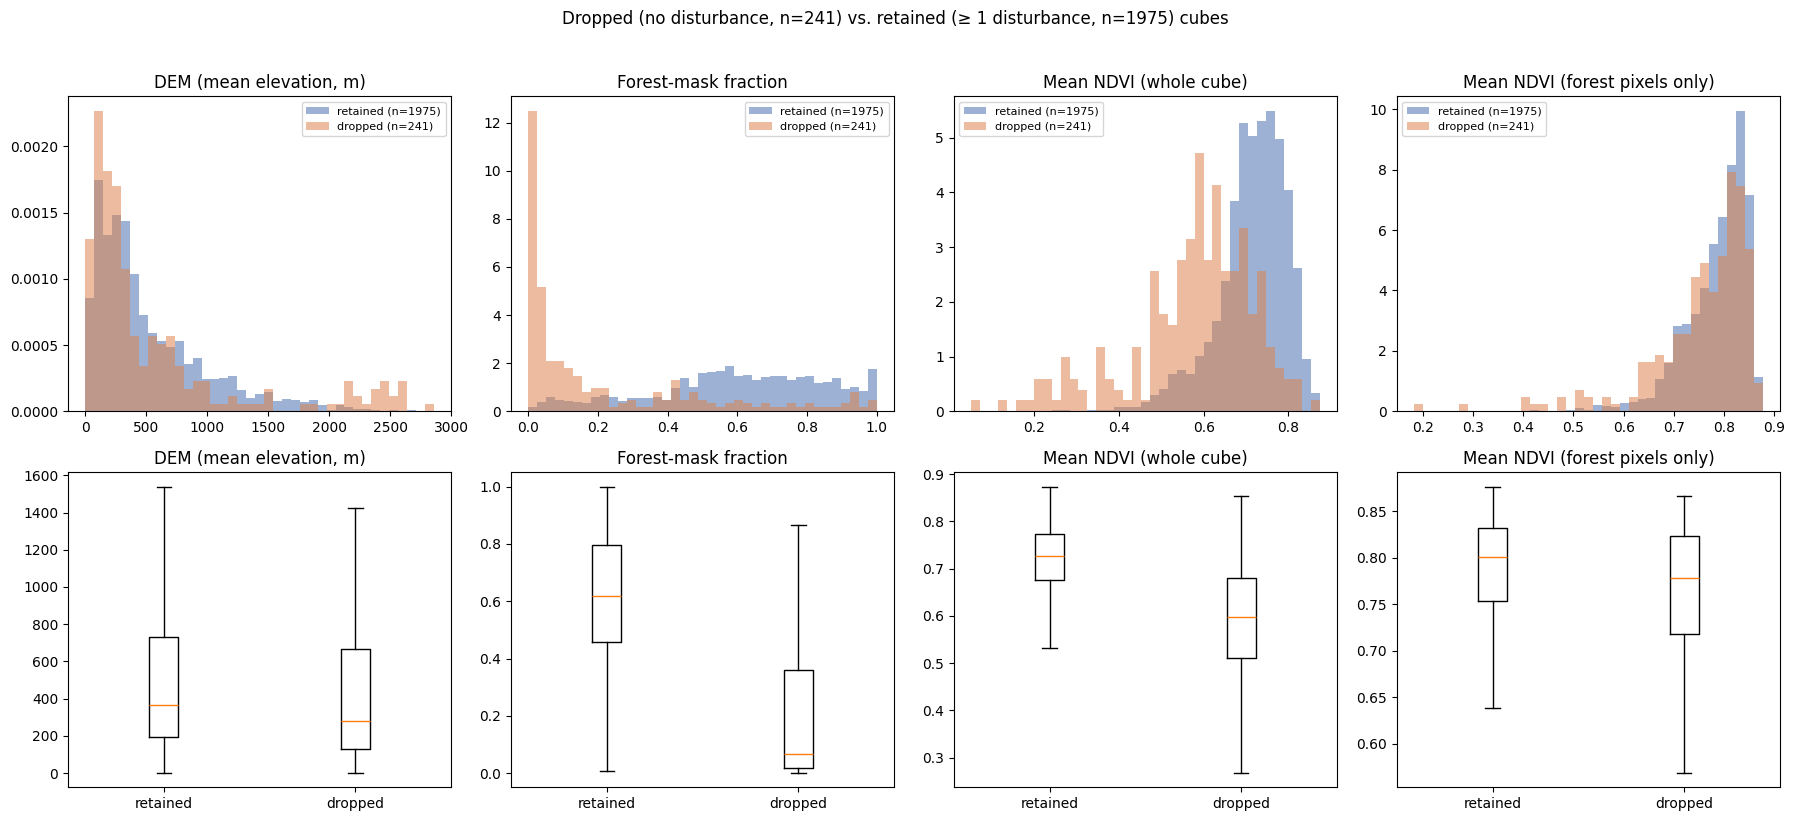

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for j, col in enumerate(metrics):
    a = df.loc[df['dropped'], col].dropna()
    b = df.loc[~df['dropped'], col].dropna()

    ax_hist = axes[0, j]
    bins = np.linspace(
        min(a.min(), b.min()), max(a.max(), b.max()), 40
    )
    ax_hist.hist(b, bins=bins, alpha=0.55, density=True, label=f'retained (n={len(b)})', color='#4C72B0')
    ax_hist.hist(a, bins=bins, alpha=0.55, density=True, label=f'dropped (n={len(a)})', color='#DD8452')
    ax_hist.set_title(labels[col])
    ax_hist.legend(fontsize=8)

    ax_box = axes[1, j]
    ax_box.boxplot([b, a], tick_labels=['retained', 'dropped'], showfliers=False)
    ax_box.set_title(labels[col])

fig.suptitle('Dropped (no disturbance, n=241) vs. retained (≥ 1 disturbance, n=1975) cubes', y=1.02)
fig.tight_layout()
plt.show()


## 6. Conclusion

**The landscape-type hypothesis is confirmed, but not in the form originally proposed.**

- **Forest-mask fraction** differs enormously (Cohen's d ≈ -1.6, Mann-Whitney p ≈ 2e-73):
  dropped cubes have a median forest fraction around **7%** vs. **62%** for retained cubes. Most of
  the 241 dropped cubes aren't disturbance-free *forest* — they're landscapes that are mostly
  non-forest to begin with, so the `disturbances` layer (which only fires on forest) had almost
  nothing to trigger on regardless of the region's actual disturbance history.
- **Mean NDVI over the whole cube** also differs a lot (d ≈ -1.5), but that's largely
  downstream of the forest-fraction gap — a cube that's mostly bare ground / water / agriculture
  will have lower average NDVI than a cube that's mostly closed-canopy forest, independent of any
  drought or stress story.
- Restricting NDVI to **forest pixels only** isolates the "is the forest that's there different"
  question from the "is there less forest" question. The gap shrinks a lot (d ≈ -0.47) but does
  not vanish, and stays highly significant (p ≈ 4e-5): where dropped cubes do have forest, that
  forest is measurably — if modestly — less vigorous/greener than the forest in retained cubes.
- **DEM/elevation is essentially a non-factor** (d ≈ 0.09, Welch p ≈ 0.34): dropped and
  retained cubes sit at statistically indistinguishable mean elevations. The "accessible terrain"
  clause of the hypothesis, at least as elevation proxies for it, is not supported by this data.
  (Caveat: raw elevation is a weak proxy for accessibility — slope/ruggedness would be a sharper
  test, and isn't available as a precomputed variable here.)

**So: it's a real selection effect, but a more mundane one than "the filter dropped protected,
climatically stable old-growth."** The dominant mechanism is land-cover composition — the 241
dropped cubes are disproportionately non-forest or sparsely-forested landscape, which mechanically
suppresses the chance of ever recording a forest-disturbance pixel — layered with a smaller, still
real difference in vegetation vigor within whatever forest those cubes do contain. Terrain
accessibility, at least via elevation, doesn't appear to be part of the story. This means the filter
in `Data-prep.ipynb` isn't just discarding "easy negatives" drawn from the same covariate
distribution as the positives — it changed the mix of land-cover types the model was trained and
evaluated on, and that should be stated as a real limitation, not a hedge.